# **Data Construction**

In [ ]:
import requests
import pandas as pd
from tqdm import tqdm

In [ ]:
appid_dict = {
    2357570: "Overwatch® 2",
    954850: "Kerbal Space Program 2",
    1716740: "Starfield",
}

In [ ]:
def fetch_steam_reviews(appid, game_name, num_pages=50):
    all_reviews = []
    cursor = "*"

    for _ in tqdm(range(num_pages), desc=f"Fetching {game_name}"):
        url = f"https://store.steampowered.com/appreviews/{appid}"
        params = {
            "json": 1,
            "language": "english",
            "filter": "all",
            "purchase_type": "all",
            "num_per_page": 100,
            "cursor": cursor
        }

        response = requests.get(url, params=params)
        if response.status_code != 200:
            break

        data = response.json()
        reviews = data.get("reviews", [])

        if not reviews:
            break

        for r in reviews:
            author = r.get("author", {})

            all_reviews.append({
                "appid": appid,
                "game_name": game_name,
                "review_id": r.get("recommendationid"),
                "review_text": r.get("review"),
                "recommendation": r.get("voted_up"),
                "votes_up": r.get("votes_up"),
                "votes_funny": r.get("votes_funny"),
                "weighted_vote_score": r.get("weighted_vote_score"),
                "comment_count": r.get("comment_count"),
                "steam_purchase": r.get("steam_purchase"),
                "received_for_free": r.get("received_for_free"),
                "written_during_early_access": r.get("written_during_early_access"),
                "author_num_games_owned": author.get("num_games_owned"),
                "author_num_reviews": author.get("num_reviews"),
                "author_playtime_forever": author.get("playtime_forever"),
                "author_playtime_last_two_weeks": author.get("playtime_last_two_weeks"),
                "author_playtime_at_review": author.get("playtime_at_review"),
                "author_last_played": author.get("last_played"),
                "timestamp_created": r.get("timestamp_created"),
                "timestamp_updated": r.get("timestamp_updated"),
                "language": r.get("language")
            })

        cursor = data.get("cursor")
        if not cursor:
            break

    return pd.DataFrame(all_reviews)

In [ ]:
all_dfs = []

for appid, game_name in appid_dict.items():
    df = fetch_steam_reviews(appid, game_name, num_pages=50)
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)

Fetching Starfield: 100%|██████████| 50/50 [00:10<00:00,  4.88it/s]


In [ ]:
final_df.shape

(13030, 21)

In [ ]:
final_df.columns

Index(['appid', 'game_name', 'review_id', 'review_text', 'recommendation',
       'votes_up', 'votes_funny', 'weighted_vote_score', 'comment_count',
       'steam_purchase', 'received_for_free', 'written_during_early_access',
       'author_num_games_owned', 'author_num_reviews',
       'author_playtime_forever', 'author_playtime_last_two_weeks',
       'author_playtime_at_review', 'author_last_played', 'timestamp_created',
       'timestamp_updated', 'language'],
      dtype='object')

In [ ]:
final_df.sample(5)

,appid,game_name,review_id,review_text,recommendation,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,...,written_during_early_access,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,timestamp_created,timestamp_updated,language
6694,954850,Kerbal Space Program 2,214719589,Don`t forget that this is the best we have.,True,0,3,0.456431567668914795,2,False,...,True,28,1,1539,466,1050,1768143353,1767171845,1767171845,english
9818,1716740,Starfield,214783081,This game is full and i mean FULL of glitches....,False,2,0,0.5,0,True,...,False,0,1,1122,0,1122,1767231415,1767232166,1767232166,english
5332,954850,Kerbal Space Program 2,208508983,"No. Just no. Fuck Take-Two, fuck Haveli Invest...",False,5,0,0.526813864707946777,0,True,...,True,921,49,301,0,301,1703717124,1762378714,1762378714,english
3956,2357570,Overwatch® 2,214496317,trash. wish i could get my time back.,False,0,0,0.5,0,False,...,False,103,6,18485,0,18485,1765340822,1766967439,1766967439,english
6386,954850,Kerbal Space Program 2,213395622,they fired everyone and abandoned the game . b...,False,4,0,0.509229779243469238,0,True,...,True,0,1,1465,0,1465,1705034301,1765855075,1765855075,english


In [ ]:
review_only_df = final_df[["review_text", "recommendation"]].copy()

In [ ]:
review_only_df.sample(5)

,review_text,recommendation
6135,Absolute travesty what was done to this game a...,False
756,despite all the hate this game is really fun c...,True
12997,I have wasted 60 hours playing this game. No a...,False
8771,Best loading screen simulator Ive ever played.,False
2229,big balls industry,True


In [ ]:
negative_df = review_only_df[review_only_df["recommendation"] == False].copy()

In [ ]:
negative_df.shape

(7860, 2)

In [ ]:
negative_df.to_csv("steam_negative_reviews.csv", index=False)

# **SVM TF-IDF**

In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
df = pd.read_csv("steam_negative_reviews.csv")

In [ ]:
df = df[df['rage'].isin([0, 1])]
df = df[['review_text', 'rage']]
df = df.dropna()

In [ ]:
print(df['rage'].value_counts())
print(df.head())

rage
1.0    501
0.0    500
Name: count, dtype: int64
                                         review_text  rage
0  notice: the reason my hours are so low is beca...   0.0
1  This game was fun for a long while.\nThen Over...   0.0
2  Stopped playing for a over year, try to get ba...   0.0
3  Overwatch 2 is not a sequel, it is a rebrand w...   0.0
4  I’ve been playing Overwatch since the OW1 Clos...   0.0


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['review_text'] = df['review_text'].apply(clean_text)

In [ ]:
df.head()

,review_text,rage
0,notice: the reason my hours are so low is beca...,0.0
1,this game was fun for a long while. then overw...,0.0
2,"stopped playing for a over year, try to get ba...",0.0
3,"overwatch 2 is not a sequel, it is a rebrand w...",0.0
4,i’ve been playing overwatch since the ow1 clos...,0.0


In [ ]:
X = df['review_text']
y = df['rage']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_test.to_csv("test_reviews.csv", index=False)

In [ ]:
X_test.shape

(201,)

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
print(X_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 19653 stored elements and shape (201, 5000)>
  Coords	Values
  (0, 90)	0.279116686432013
  (0, 119)	0.1256553367438609
  (0, 191)	0.15315507938496653
  (0, 1249)	0.18180081196809383
  (0, 1496)	0.2621869673890463
  (0, 1522)	0.3090077295226322
  (0, 1921)	0.09815340441946357
  (0, 1958)	0.19505967000537677
  (0, 2446)	0.17702979448441855
  (0, 2638)	0.13955327512974594
  (0, 2723)	0.15044888399578613
  (0, 2795)	0.17702979448441855
  (0, 2817)	0.08877453163265145
  (0, 2857)	0.13150702154786803
  (0, 3661)	0.12116145105078392
  (0, 3676)	0.19615333705391821
  (0, 3933)	0.20200502185792532
  (0, 4002)	0.14702629083690974
  (0, 4052)	0.11027126396178605
  (0, 4285)	0.08155090287505704
  (0, 4291)	0.09688199925468637
  (0, 4344)	0.07983850008701773
  (0, 4433)	0.15565705138571187
  (0, 4538)	0.3090077295226322
  (0, 4579)	0.4770194584251498
  :	:
  (198, 4693)	0.06683706892025952
  (198, 4742)	0.0356318323470541
  (198, 4819)	0

In [ ]:
svm = LinearSVC(C=1.0, random_state=42)
svm.fit(X_train_tfidf, y_train)

LinearSVC(random_state=42)

In [ ]:
y_pred = svm.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Reason", "Rage"]))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8208955223880597

Classification Report:

              precision    recall  f1-score   support

      Reason       0.81      0.84      0.82       100
        Rage       0.84      0.80      0.82       101

    accuracy                           0.82       201
   macro avg       0.82      0.82      0.82       201
weighted avg       0.82      0.82      0.82       201


Confusion Matrix:

[[84 16]
 [20 81]]


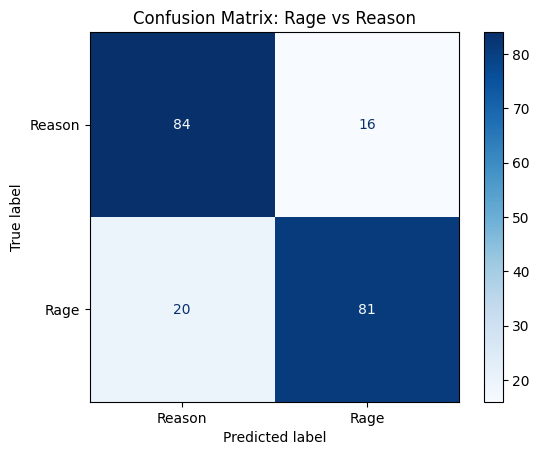

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Reason", "Rage"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: Rage vs Reason")
plt.show()


In [ ]:
df['char_count'] = df['review_text'].apply(len)

In [ ]:
df.head()

,review_text,rage,char_count
0,notice: the reason my hours are so low is beca...,0.0,2358
1,this game was fun for a long while. then overw...,0.0,582
2,"stopped playing for a over year, try to get ba...",0.0,446
3,"overwatch 2 is not a sequel, it is a rebrand w...",0.0,696
4,i’ve been playing overwatch since the ow1 clos...,0.0,1262


In [ ]:
avg_counts = df.groupby('rage')['char_count'].mean()

print("Average character count:")
print("Reason (0):", avg_counts[0])
print("Rage (1):", avg_counts[1])

Average character count:
Reason (0): 1105.036
Rage (1): 183.4431137724551


In [ ]:
df['word_count'] = df['review_text'].apply(lambda x: len(x.split()))

avg_words = df.groupby('rage')['word_count'].mean()

print("\nAverage word count:")
print("Reason (0):", avg_words[0])
print("Rage (1):", avg_words[1])



Average word count:
Reason (0): 197.754
Rage (1): 33.8063872255489


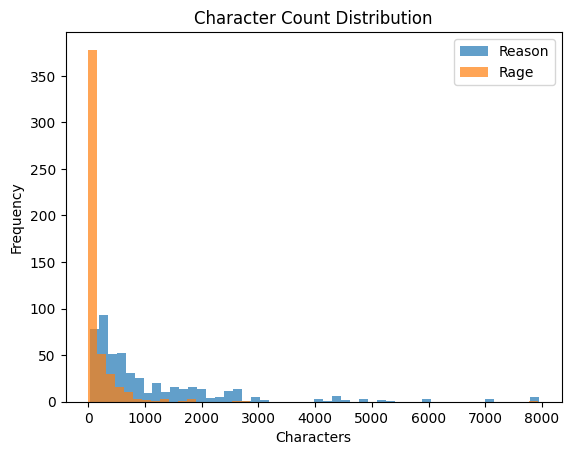

In [ ]:
import matplotlib.pyplot as plt

plt.hist(
    df[df['rage'] == 0]['char_count'],
    bins=50,
    alpha=0.7,
    label='Reason'
)

plt.hist(
    df[df['rage'] == 1]['char_count'],
    bins=50,
    alpha=0.7,
    label='Rage'
)

plt.legend()
plt.title("Character Count Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

# **LLM Zero-Shot**

In [ ]:
!pip install -q transformers torch accelerate

In [ ]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


In [ ]:
labels = [
    "emotionally angry rant with insults or venting that lacks clear explanation of specific problems in the game",
    "constructive criticism that explains specific problems or design flaws in a way developers can understand and act on, even if the tone is harsh"
]

In [ ]:
def zero_shot_classify_local(text):
    result = classifier(
        text,
        labels,
        hypothesis_template="This review is {}."
    )

    label = result["labels"][0]

    if "angry" in label:
        return 1  # rage
    else:
        return 0


In [ ]:
from tqdm import tqdm

y_pred_zs = []

for text in tqdm(X_test.tolist()):
    pred = zero_shot_classify_local(text)
    y_pred_zs.append(pred)


100%|██████████| 201/201 [00:37<00:00,  5.42it/s]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_zs, target_names=["Reason", "Rage"]))

              precision    recall  f1-score   support

      Reason       0.67      0.35      0.46       100
        Rage       0.56      0.83      0.67       101

    accuracy                           0.59       201
   macro avg       0.62      0.59      0.57       201
weighted avg       0.62      0.59      0.57       201



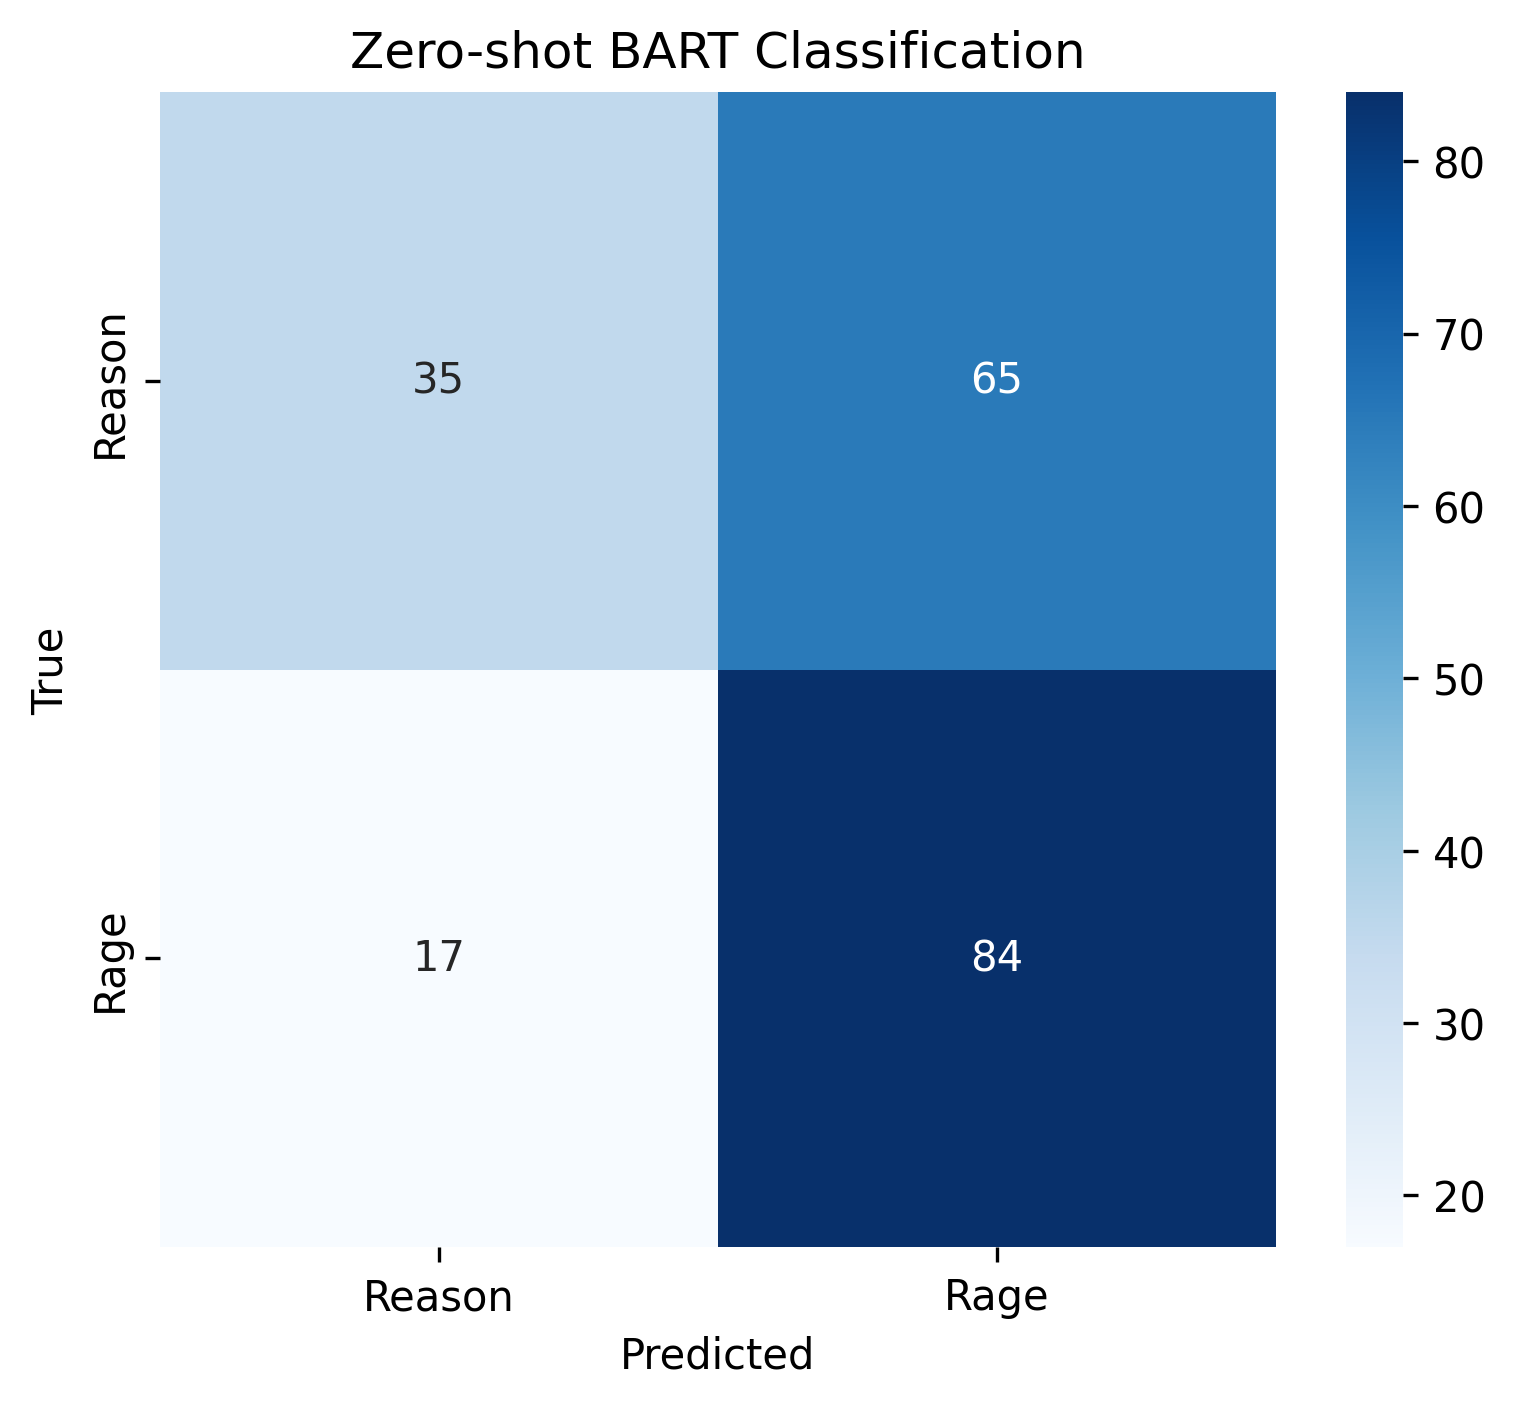

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_zs)

plt.figure(figsize=(6, 5), dpi=300)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Reason", "Rage"],
    yticklabels=["Reason", "Rage"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Zero-shot BART Classification")
plt.show()


# **Few Shot**

In [ ]:
test_df = pd.DataFrame({
    "review_text": X_train,
    "rage": y_train
})

In [ ]:
test_df.sample(10)

,review_text,rage
461,"matchmaking feels inconsistent, hero balance s...",0.0
688,the most toxic gaming community i have ever co...,1.0
770,fucking joke of a game,1.0
679,this game is a fucking joke. the report system...,1.0
110,"story is extremely dull, rpg elements are lack...",0.0
155,the game is fun and enjoyable but in long term...,0.0
866,a waste of time; not even modders support this...,1.0
481,cannot play the fucking game. old number i use...,0.0
622,i have probably around 150 hours on microsoft ...,1.0
29,"terrible game, first gives me issues in making...",0.0


In [ ]:
from transformers import pipeline

fewshot_model = pipeline(
    "text2text-generation",
    model="google/flan-t5-large",
    device=0
)

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


In [ ]:
def few_shot_prompt(review_text):
    return f"""
You are classifying negative game reviews into two categories:

Rage:
Emotionally angry rant with insults or venting that lacks clear explanation of specific problems in the game.

Reason:
Constructive criticism that explains specific problems or design flaws in a way developers can understand and act on, even if the tone is harsh.

Examples:

Review:
"this game is trash and the devs are idiots. absolute garbage experience."
Label: Rage

Review:
"the matchmaking system feels unfair because new players are consistently placed against high-rank opponents, making progression frustrating."
Label: Reason

Review:
"this season balancing is trash. juno does too much damage for a support and has mobility comparable to dps characters."
Label: Reason

Review:
"worst game ever. uninstalling immediately. waste of money."
Label: Rage

Now classify this review:

Review: "{review_text}"
Label:
"""

In [ ]:
def few_shot_classify(text):
    output = fewshot_model(
        few_shot_prompt(text),
        max_new_tokens=5,
        do_sample=False
    )[0]["generated_text"].lower()

    if "rage" in output:
        return 1
    elif "reason" in output:
        return 0
    else:
        return None

In [ ]:
from tqdm import tqdm

y_pred_fewshot = []

for text in tqdm(X_test.tolist()):
    pred = few_shot_classify(text)
    y_pred_fewshot.append(pred)


100%|██████████| 201/201 [01:04<00:00,  3.11it/s]


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

mask = [p is not None for p in y_pred_fewshot]

print(
    classification_report(
        y_test[mask],
        np.array(y_pred_fewshot)[mask],
        target_names=["Reason", "Rage"]
    )
)


              precision    recall  f1-score   support

      Reason       0.72      0.13      0.22       100
        Rage       0.52      0.95      0.68       101

    accuracy                           0.54       201
   macro avg       0.62      0.54      0.45       201
weighted avg       0.62      0.54      0.45       201



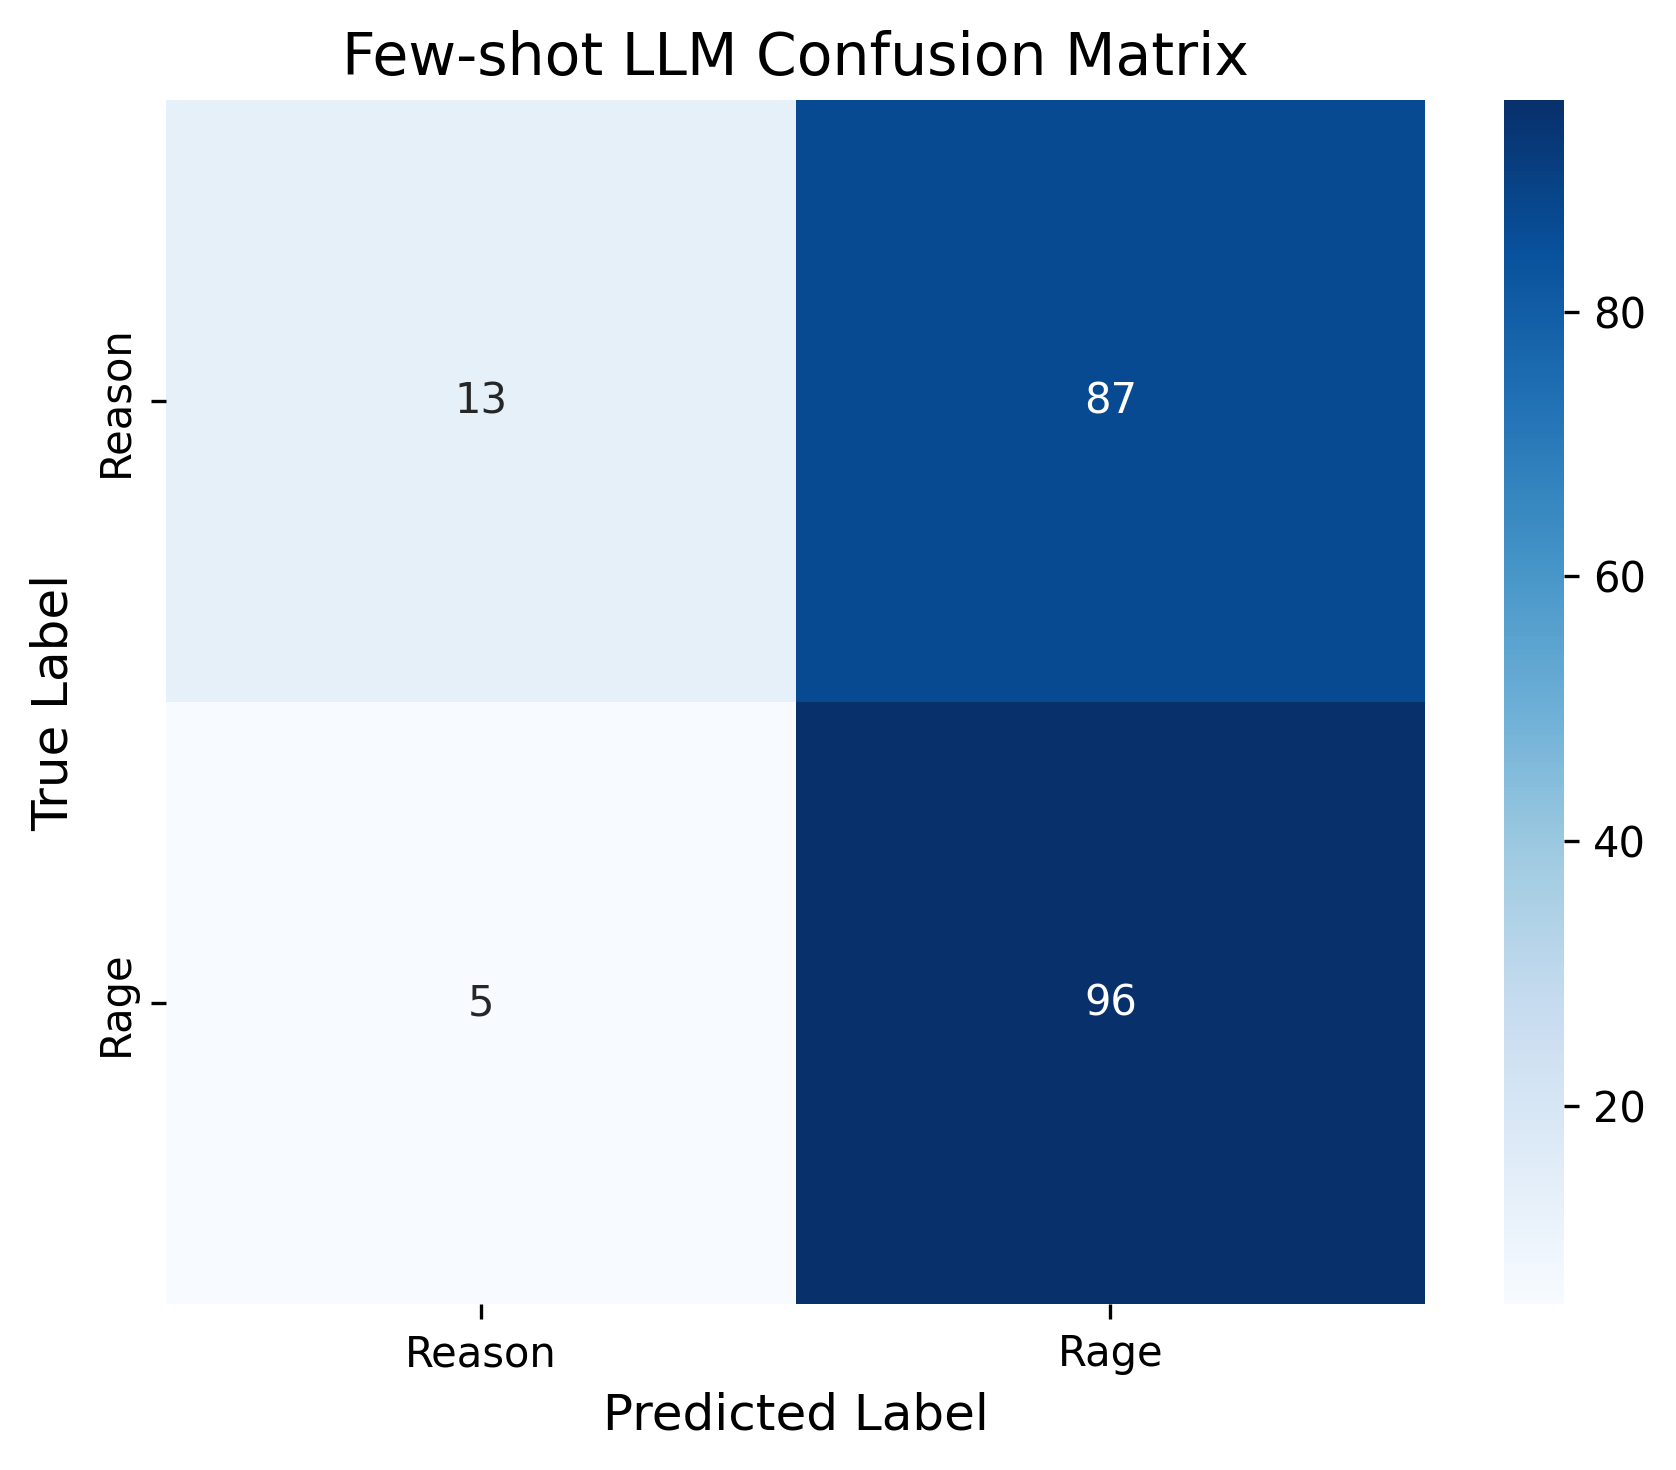

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert to numpy arrays (safety)
y_true = np.array(y_test)
y_pred = np.array(y_pred_fewshot)

# If you filtered None values earlier, apply the same mask here
mask = y_pred != None
y_true = y_true[mask]
y_pred = y_pred[mask].astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6, 5), dpi=300)  # high quality
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Reason", "Rage"],
    yticklabels=["Reason", "Rage"]
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Few-shot LLM Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()
